<a href="https://colab.research.google.com/github/Ishany0/Liver-disease-detection-using-ultrasound-imaging/blob/main/using_vgg_and_feedforward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
path = kagglehub.dataset_download("mahendarbyra/behsof-dataset")

print("Path to dataset files:", path)

100%|██████████| 319M/319M [00:02<00:00, 155MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mahendarbyra/behsof-dataset/versions/1


In [3]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "  " * (level + 1)
    for f in files[:5]:  # show first 5 files per folder to keep it readable
        print(f"{subindent}{f}")
    if len(files) > 5:
        print(f"{subindent}... ({len(files)} files total)")

1/
  BEHSOF/
    NAFLD/
      nafld_1396.jpg
      nafld_776.jpg
      nafld_1093.jpg
      nafld_272.jpg
      nafld_24.jpg
      ... (1517 files total)
    Non-NAFLD/
      non_nafld_68.jpg
      non_nafld_115.jpg
      non_nafld_128.jpg
      non_nafld_114.jpg
      non_nafld_113.jpg
      ... (152 files total)


In [4]:
PREPROCESS_FUNC = tf.keras.applications.mobilenet_v2.preprocess_input

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    zoom_range=0.1,
)

dev_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = dev_datagen

In [6]:
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split

src = Path(path) / "BEHSOF"
out = Path("BEHSOF_split")

for cls in ['NAFLD','Non-NAFLD']:
  files = list((src/cls).glob('*.jpg'))
  train , temp = train_test_split(files , test_size = 0.3, random_state = 42)
  dev , test = train_test_split(temp, test_size = 0.5 , random_state = 42)
  for split , flist in zip(['train' , 'dev' , 'test'] , [train , dev , test]):
    d = out / split / cls
    d.mkdir(parents = True , exist_ok = True)
    for f in flist:
      shutil.copy(f,d / f.name)

print("Done: ", out.resolve())

Done:  /content/BEHSOF_split


In [7]:
import os
for split in ["train", "dev", "test"]:
    for cls in ["NAFLD", "Non-NAFLD"]:
        d = f"/content/BEHSOF_split/{split}/{cls}"
        print(split, cls, len(os.listdir(d)))

train NAFLD 1061
train Non-NAFLD 106
dev NAFLD 228
dev Non-NAFLD 23
test NAFLD 228
test Non-NAFLD 23


In [13]:
train_dataset = train_datagen.flow_from_directory(
    "/content/BEHSOF_split/train",
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=True,
)

dev_dataset = dev_datagen.flow_from_directory(
    "/content/BEHSOF_split/dev",
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
)

test_dataset = test_datagen.flow_from_directory(
    "/content/BEHSOF_split/test",
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
)

Found 1167 images belonging to 2 classes.
Found 251 images belonging to 2 classes.
Found 251 images belonging to 2 classes.


In [21]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
vgg_base.trainable = False

model = Sequential([
    vgg_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])



In [22]:
from tensorflow.keras.metrics import Precision, Recall, AUC

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
    ]
)

In [23]:
history = model.fit(train_dataset, epochs=10, validation_data=dev_dataset)

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1294s 35s/step - accuracy: 0.8689 - auc: 0.5814 - loss: 1.2646 - precision: 0.1594 - recall: 0.1038 - val_accuracy: 0.9084 - val_auc: 0.8698 - val_loss: 0.2252 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1284s 35s/step - accuracy: 0.9057 - auc: 0.7821 - loss: 0.2666 - precision: 0.3333 - recall: 0.0377 - val_accuracy: 0.9084 - val_auc: 0.8981 - val_loss: 0.2123 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1315s 36s/step - accuracy: 0.9100 - auc: 0.8543 - loss: 0.2305 - precision: 0.5556 - recall: 0.0472 - val_accuracy: 0.9084 - val_auc: 0.9037 - val_loss: 0.2640 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1265s 34s/step - accuracy: 0.9135 - auc: 0.8955 - loss: 0.2033 - precision: 0.5862 - recall: 0.1604 - val_accuracy: 0.9044 - val_auc: 0.9487 - val_loss: 0.1965 - val_precision: 0.0000e+00 - val_recall: 0.0000e

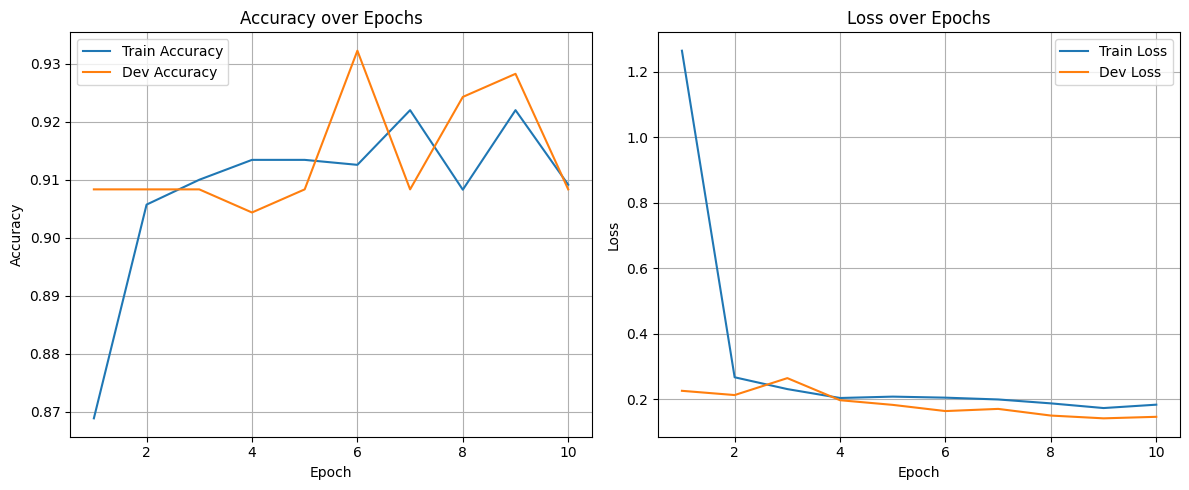

In [24]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Dev Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Dev Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Evaluating on test dataset:
8/8 ━━━━━━━━━━━━━━━━━━━━ 222s 28s/step - accuracy: 0.9084 - auc: 0.9581 - loss: 0.1564 - precision: 0.0000e+00 - recall: 0.0000e+00
ACCURACY: 0.9083665609359741
LOSS: 0.15638747811317444
8/8 ━━━━━━━━━━━━━━━━━━━━ 221s 27s/step
Best Threshold (from dev): 0.35678391959798994
Best F1 (dev): 0.7083333333333334
8/8 ━━━━━━━━━━━━━━━━━━━━ 221s 28s/step
classification report:
               precision    recall  f1-score   support

       NAFLD       0.97      0.96      0.97       228
   Non-NAFLD       0.67      0.70      0.68        23

    accuracy                           0.94       251
   macro avg       0.82      0.83      0.82       251
weighted avg       0.94      0.94      0.94       251

Overall Accuracy: 0.9402390438247012
Sensitivity (Recall for positive class): 0.6956521739130435
Specificity (Recall for negative class): 0.9649122807017544
AUC SCORE: 0.9581426392067124


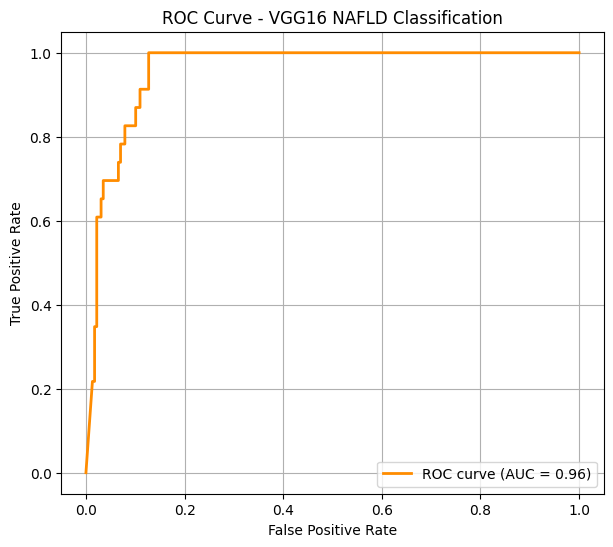

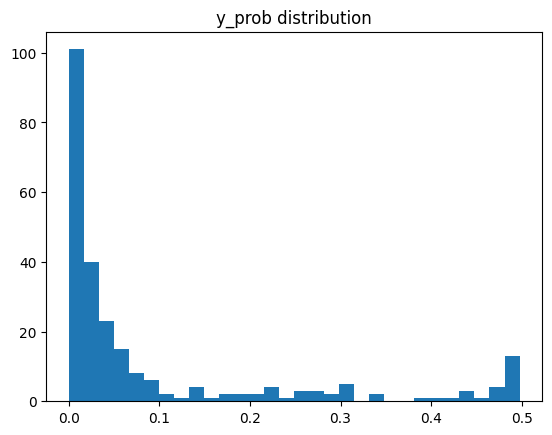

In [26]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score



print("Evaluating on test dataset:")
results = model.evaluate(test_dataset)
loss = results[0]
accuracy = results[1]
print("ACCURACY:", accuracy)
print("LOSS:", loss)

# --- get labels + probs for DEV set (for threshold tuning) ---
dev_dataset.reset()
y_dev_true = dev_dataset.classes
y_dev_prob = model.predict(dev_dataset, steps=len(dev_dataset)).ravel()

# --- threshold tuning on DEV set, not test ---
thresholds = np.linspace(0, 1, 200)
best_f1, best_t = 0, 0.5
for t in thresholds:
    temp_pred = (y_dev_prob >= t).astype(int)
    f1 = f1_score(y_dev_true, temp_pred)
    if f1 > best_f1:
        best_f1, best_t = f1, t
print("Best Threshold (from dev):", best_t)
print("Best F1 (dev):", best_f1)

# --- get labels + probs for TEST set (final, unbiased eval) ---
test_dataset.reset()
y_true = test_dataset.classes
y_prob = model.predict(test_dataset, steps=len(test_dataset)).ravel()

predicted_results = (y_prob >= best_t).astype(int)

class_names = list(test_dataset.class_indices.keys())
print("classification report:\n", classification_report(y_true, predicted_results, target_names=class_names))

cm = confusion_matrix(y_true, predicted_results)
accuracy = (cm[0, 0] + cm[1, 1]) / np.sum(cm)
print("Overall Accuracy:", accuracy)

TN, FP, FN, TP = cm.ravel()
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
print("Sensitivity (Recall for positive class):", sensitivity)
print("Specificity (Recall for negative class):", specificity)

auc_score = roc_auc_score(y_true, y_prob)
print('AUC SCORE:', auc_score)

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - VGG16 NAFLD Classification')
plt.grid(True)
plt.show()

plt.hist(y_prob, bins=30)
plt.title("y_prob distribution")
plt.show()